# 1. Data collection, cleaning, analysis and expansion of historical data
---
## Step 1.1: Loading libraries and dependencies

In [2]:
# Basics
import os
from datetime import datetime, timedelta
from configparser import ConfigParser
import ta

# Data manipulation
import pandas as pd
import numpy as np

# Timezone
import pytz
from pytz import timezone

# Information visualisation
import matplotlib.pyplot as plt

# Deep Learning; TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# Machine Learning; Scikit-learn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
import joblib
from imblearn.over_sampling import RandomOverSampler

# API Alpaca
import alpaca_trade_api as tradeapi
from alpaca.data import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit
from alpaca.data.enums import Adjustment, DataFeed


## Step 1.2: Loading Alpaca API credentials

In [3]:
config = ConfigParser()
config.read("../params/config.ini")
key = config['alpaca_account']['key']
secret = config['alpaca_account']['secret']
base_paper_url = "https://paper-api.alpaca.markets/v2"

api = tradeapi.REST(key, secret, base_paper_url, api_version='v2')

## Step 1.3: Downloading historical data

In [4]:
def telecharger_donnees_histo(symbol, debut, fin, timeframe='1Min', fichier_csv="donnees.csv"):
    debut_dt = datetime.strptime(debut, "%Y-%m-%d")
    fin_dt = datetime.strptime(fin, "%Y-%m-%d")

    all_data = []

    jour = debut_dt
    while jour <= fin_dt:
        try :
            start_dt = datetime.combine(jour, datetime.strptime("13:30", "%H:%M").time())
            end_dt = datetime.combine(jour, datetime.strptime("20:00", "%H:%M").time())

            start_str = start_dt.isoformat() + "Z"
            end_str = end_dt.isoformat() + "Z"
            bars = api.get_bars(
                symbol,
                timeframe,
                start=start_str,
                end=end_str
            ).df

            if not bars.empty:
                df_day = bars.copy()
                df_day.index = df_day.index.tz_convert('UTC')
                df_day = df_day[['open', 'high', 'low', 'close', 'volume']]
                all_data.append(df_day)
            else:
                print(f"Info : Aucune donnée pour {symbol} le {jour.strftime('%Y-%m-%d')}")

        except Exception as e:
            print(f"Erreur : {jour.strftime('%Y-%m-%d')} : {e}")
        
        jour += timedelta(days=1)

    if not all_data:
        print("Erreur : Aucune donnée récupérée.")
        return

    df_final = pd.concat(all_data)
    df_final.to_csv(fichier_csv)
    print(f"Succès : Données sauvegardées dans : {fichier_csv}")

In [5]:
telecharger_donnees_histo(
    symbol="AAPL",
    debut="2023-05-01",
    fin="2023-06-30",
    timeframe='1Min',
    fichier_csv="../data/AAPL_mai_2023.csv"
)

Info : Aucune donnée pour AAPL le 2023-05-06
Info : Aucune donnée pour AAPL le 2023-05-07
Info : Aucune donnée pour AAPL le 2023-05-13
Info : Aucune donnée pour AAPL le 2023-05-14
Info : Aucune donnée pour AAPL le 2023-05-20
Info : Aucune donnée pour AAPL le 2023-05-21
Info : Aucune donnée pour AAPL le 2023-05-27
Info : Aucune donnée pour AAPL le 2023-05-28
Info : Aucune donnée pour AAPL le 2023-05-29
Info : Aucune donnée pour AAPL le 2023-06-03
Info : Aucune donnée pour AAPL le 2023-06-04
Info : Aucune donnée pour AAPL le 2023-06-10
Info : Aucune donnée pour AAPL le 2023-06-11
Info : Aucune donnée pour AAPL le 2023-06-17
Info : Aucune donnée pour AAPL le 2023-06-18
Info : Aucune donnée pour AAPL le 2023-06-19
Info : Aucune donnée pour AAPL le 2023-06-24
Info : Aucune donnée pour AAPL le 2023-06-25
Succès : Données sauvegardées dans : ../data/AAPL_mai_2023.csv


## Step 1.4: Preparing the CSV file

In [6]:
df_hist = pd.read_csv("../data/AAPL_mai_2023.csv", parse_dates=['timestamp'])
df_hist = df_hist.set_index('timestamp')
df_hist = df_hist.sort_index() 
df_hist.head()

,open,high,low,close,volume
timestamp,,,,,
2023-05-01 13:30:00+00:00,169.28,169.8500,169.2800,169.8236,1422421
2023-05-01 13:31:00+00:00,169.83,169.9200,169.5500,169.6415,304499
2023-05-01 13:32:00+00:00,169.65,169.7806,169.5600,169.7500,232898
2023-05-01 13:33:00+00:00,169.75,169.8700,169.6000,169.6000,192009
2023-05-01 13:34:00+00:00,169.62,169.7100,169.4037,169.4390,251297


## Step 1.5: Calculation of technical indicators

In [7]:
window = 14

df_hist['change1m'] = df_hist['close'].pct_change() * 100
df_hist['volatilite'] = df_hist['close'].rolling(10).std()
df_hist['perf_open'] = ((df_hist['close'] - df_hist['open'].iloc[0]) / df_hist['open'].iloc[0]) * 100

# RSI
delta = df_hist['close'].diff()
gain = delta.where(delta > 0, 0).rolling(window=window).mean()
loss = -delta.where(delta < 0, 0).rolling(window=window).mean()
rs = gain / loss
df_hist['RSI'] = 100 - (100 / (1 + rs))

# MACD
df_hist['EMA_6'] = df_hist['close'].ewm(span=6).mean()
df_hist['EMA_12'] = df_hist['close'].ewm(span=12).mean()
df_hist['MACD'] = df_hist['EMA_6'] - df_hist['EMA_12']

# Bollinger Bands
df_hist['SMA'] = df_hist['close'].rolling(window=window).mean()
df_hist['STD'] = df_hist['close'].rolling(window=window).std()
df_hist['Bollinger_%B'] = (df_hist['close'] - (df_hist['SMA'] - 2 * df_hist['STD'])) / (4 * df_hist['STD'])

# OBV
df_hist['OBV'] = np.where(
    df_hist['close'] > df_hist['close'].shift(1), df_hist['volume'],
    np.where(df_hist['close'] < df_hist['close'].shift(1), -df_hist['volume'], 0)
).cumsum()

# ADX
def calculate_adx(df, window=14):
    df = df.copy()
    df['TR'] = np.maximum(df['high'] - df['low'],
                          np.maximum(abs(df['high'] - df['close'].shift(1)),
                                     abs(df['low'] - df['close'].shift(1))))
    df['+DM'] = np.where((df['high'] - df['high'].shift(1)) > (df['low'].shift(1) - df['low']),
                         np.maximum(df['high'] - df['high'].shift(1), 0), 0)
    df['-DM'] = np.where((df['low'].shift(1) - df['low']) > (df['high'] - df['high'].shift(1)),
                         np.maximum(df['low'].shift(1) - df['low'], 0), 0)

    tr_smooth = df['TR'].rolling(window=window).sum()
    plus_dm_smooth = df['+DM'].rolling(window=window).sum()
    minus_dm_smooth = df['-DM'].rolling(window=window).sum()

    plus_di = 100 * (plus_dm_smooth / tr_smooth)
    minus_di = 100 * (minus_dm_smooth / tr_smooth)
    dx = (abs(plus_di - minus_di) / (plus_di + minus_di)) * 100
    adx = dx.rolling(window=window).mean()
    df['ADX'] = adx
    return df

df_hist = calculate_adx(df_hist, window=14)

# Autres indicateurs via ta-lib ou pandas-ta
df_hist['EMA50'] = ta.trend.ema_indicator(df_hist['close'], window=50).fillna(method='bfill')
df_hist['EMA200'] = ta.trend.ema_indicator(df_hist['close'], window=200).fillna(method='bfill')
df_hist['ATR'] = ta.volatility.average_true_range(df_hist['high'], df_hist['low'], df_hist['close'], window=14).fillna(method='bfill')
df_hist['CCI'] = ta.trend.cci(df_hist['high'], df_hist['low'], df_hist['close'], window=20).fillna(method='bfill')
df_hist['StochRSI'] = ta.momentum.stochrsi(df_hist['close'], window=14, smooth1=3, smooth2=3).fillna(method='bfill')

# Export final
colonnes = [
    "open", "high", "low", "close", "volume",
    "change1m", "volatilite", "perf_open", "RSI", "MACD", "OBV", "Bollinger_%B", "ADX",
    "EMA50", "EMA200", "ATR", "CCI", "StochRSI"
]
df_hist = df_hist[colonnes]
df_hist.to_csv("../data/out_hist.csv")


# 2. Developing the Strategy and Identifying Trading Opportunities
---
## Step 2.1: Signal generation using the manual strategy

In [8]:
def generate_signals_from_existing_indicators(df):
    """
    Génère des signaux d'achat/vente/HOLD à partir de RSI, MACD, ADX.
    La logique est simplifiée pour refléter un comportement de trader humain.
    """
    df = df.copy()
    df['Signal'] = "HOLD"

    for i in range(2, len(df)):
        rsi = df.iloc[i]['RSI']
        rsi_prev = df.iloc[i - 1]['RSI']
        macd = df.iloc[i]['MACD']
        macd_prev = df.iloc[i - 1]['MACD']
        adx = df.iloc[i]['ADX']
        change1m = df.iloc[i]['change1m']
        vol = df.iloc[i]['volatilite']

        # Conditions générales de filtrage
        if adx < 20:
            continue  # marché sans tendance

        if vol < 0.01:
            continue  # trop peu de mouvement

        # Calcul d'un score de confiance
        score = 0

        # Critères de momentum haussier
        if rsi_prev < 30 and rsi >= 30:
            score += 1
        if macd > 0 and macd > macd_prev:
            score += 1
        if change1m > 0.1:
            score += 1

        if score >= 2:
            df.iat[i, df.columns.get_loc('Signal')] = "BUY"
            continue

        # Critères de momentum baissier
        score = 0
        if rsi_prev > 70 and rsi <= 70:
            score += 1
        if macd < 0 and macd < macd_prev:
            score += 1
        if change1m < -0.1:
            score += 1

        if score >= 2:
            df.iat[i, df.columns.get_loc('Signal')] = "SELL"

    return df


# ETAPE 2.2 : Simulation des trades avec durée & stop-loss

def generate_trades_with_duration_filter(df, min_duration=1, max_duration=300, stop_loss_pct=0.01, verbose=True):
    """
    Simule les trades à partir d'un DataFrame de signaux.
    
    Arguments :
        df : DataFrame contenant une colonne 'Signal' (BUY / SELL / HOLD)
        min_duration : durée minimale pour valider un trade (en minutes)
        max_duration : durée maximale d’un trade avant forçage de sortie
        stop_loss_pct : niveau de stop-loss en % (0.01 = 1%)
        verbose : si True, affiche les logs de chaque trade simulé
    """
    executed_trades = []
    position = None

    for i in range(len(df)):
        row = df.iloc[i]
        signal = row['Signal']
        price = row['close']
        timestamp = row.name  # utilise l'index comme timestamp

        # 🔐 Entrée en position uniquement si aucune position n'est ouverte
        if position is None and signal in ['BUY', 'SELL']:
            position = {
                'type': signal,
                'entry_price': price,
                'entry_time': timestamp,
                'entry_index': i
            }
            if verbose:
                print(f"✅ Entrée {signal} à {timestamp} @ {price:.2f}")
            continue

        # 📤 Gestion de la position ouverte
        if position is not None:
            duration = i - position['entry_index']
            stop_loss_triggered = False

            if position['type'] == 'BUY':
                stop_loss_triggered = price <= position['entry_price'] * (1 - stop_loss_pct)
            elif position['type'] == 'SELL':
                stop_loss_triggered = price >= position['entry_price'] * (1 + stop_loss_pct)

            is_opposite_signal = signal == ('SELL' if position['type'] == 'BUY' else 'BUY')

            # Conditions de sortie
            if stop_loss_triggered or duration >= max_duration or is_opposite_signal:
                exit_price = price
                exit_time = timestamp
                pnl = exit_price - position['entry_price']
                if position['type'] == 'SELL':
                    pnl = -pnl

                if duration >= min_duration:
                    trade_data = {
                        'type': position['type'],
                        'entry_price': position['entry_price'],
                        'entry_time': position['entry_time'],
                        'exit_price': exit_price,
                        'exit_time': exit_time,
                        'PnL': pnl,
                        'duration_min': duration
                    }
                    executed_trades.append(trade_data)
                    if verbose:
                        print(f"🔁 Sortie {position['type']} à {exit_time} @ {exit_price:.2f} | PnL: {pnl:.4f}, durée: {duration} min")

                position = None  # Réinitialisation

    return pd.DataFrame(executed_trades)


# ETAPE 2.3 : Création de la colonne Target pour l’IA

def define_targets(df, horizon=3, seuil=0.0015):
    df = df.copy()
    df['future_return'] = df['close'].shift(-horizon) / df['close'] - 1

    df['Target'] = 0
    df.loc[df['future_return'] > seuil, 'Target'] = 1
    df.loc[df['future_return'] < -seuil, 'Target'] = -1

    return df


In [9]:
df_with_signals = generate_signals_from_existing_indicators(df_hist)
trades_df = generate_trades_with_duration_filter(df_with_signals, min_duration=5, max_duration=300)

✅ Entrée SELL à 2023-05-01 13:35:00+00:00 @ 169.08
🔁 Sortie SELL à 2023-05-01 13:41:00+00:00 @ 169.93 | PnL: -0.8500, durée: 6 min
✅ Entrée BUY à 2023-05-01 13:52:00+00:00 @ 170.16
✅ Entrée BUY à 2023-05-01 14:02:00+00:00 @ 169.55
🔁 Sortie BUY à 2023-05-01 15:15:00+00:00 @ 169.12 | PnL: -0.4300, durée: 73 min
✅ Entrée BUY à 2023-05-01 15:20:00+00:00 @ 169.27
🔁 Sortie BUY à 2023-05-01 18:34:00+00:00 @ 169.40 | PnL: 0.1317, durée: 194 min
✅ Entrée SELL à 2023-05-01 19:33:00+00:00 @ 169.59
🔁 Sortie SELL à 2023-05-02 13:45:00+00:00 @ 169.75 | PnL: -0.1650, durée: 43 min
✅ Entrée SELL à 2023-05-02 14:01:00+00:00 @ 169.52
🔁 Sortie SELL à 2023-05-02 14:12:00+00:00 @ 169.01 | PnL: 0.5100, durée: 11 min
✅ Entrée SELL à 2023-05-02 14:22:00+00:00 @ 168.67
🔁 Sortie SELL à 2023-05-02 19:22:00+00:00 @ 169.04 | PnL: -0.3750, durée: 300 min
✅ Entrée SELL à 2023-05-02 19:45:00+00:00 @ 168.55
🔁 Sortie SELL à 2023-05-03 13:30:00+00:00 @ 169.74 | PnL: -1.1921, durée: 16 min
✅ Entrée BUY à 2023-05-03 13:34

In [10]:
# ETAPE 2.4 : Export CSV pour l’entraînement

print(df_with_signals['Signal'].value_counts())
df_with_signals.to_csv("../data/out_signal.csv")

Signal
HOLD    16304
SELL      272
BUY       237
Name: count, dtype: int64


In [11]:
# ETAPE 2.5 : Simulation finale des trades manuels

df_with_targets = define_targets(df_with_signals, horizon=3, seuil=0.0015)
df_with_targets.to_csv('../data/out_training.csv')

executed_trades = []
position = None

for i in range(len(df_with_targets)):
    signal = df_with_targets.iloc[i]['Signal']
    timestamp = df_with_targets.index[i]
    price = df_with_targets.iloc[i]['close']

    if position is None:
        if signal in ['BUY', 'SELL']:
            position = {
                'type': signal,
                'entry_price': price,
                'entry_time': timestamp  # Enregistrement du timestamp d'entrée
            }
    else:
        # Vérifie une inversion de signal pour clôturer la position
        if (signal == 'SELL' and position['type'] == 'BUY') or (signal == 'BUY' and position['type'] == 'SELL'):
            exit_price = price
            exit_time = timestamp  # Enregistrement du timestamp de sortie

            pnl = exit_price - position['entry_price']
            if position['type'] == 'SELL':
                pnl = -pnl

            executed_trades.append({
                'type': position['type'],
                'entry_price': position['entry_price'],
                'entry_time': position['entry_time'],  # Ajout du timestamp d'entrée
                'exit_price': exit_price,
                'exit_time': exit_time,                # Ajout du timestamp de sortie
                'PnL': pnl
            })

            position = None

# Transformation en DataFrame
trades_df = pd.DataFrame(executed_trades)
trades_df.to_csv('../data/out_trades.csv')
trades_df

,type,entry_price,entry_time,exit_price,exit_time,PnL
0,SELL,169.0800,2023-05-01 13:35:00+00:00,169.9300,2023-05-01 13:41:00+00:00,-0.8500
1,BUY,170.1553,2023-05-01 13:52:00+00:00,169.9500,2023-05-01 13:53:00+00:00,-0.2053
2,BUY,169.5500,2023-05-01 14:02:00+00:00,169.1200,2023-05-01 15:15:00+00:00,-0.4300
3,BUY,169.2683,2023-05-01 15:20:00+00:00,169.4000,2023-05-01 18:34:00+00:00,0.1317
4,SELL,169.5850,2023-05-01 19:33:00+00:00,169.7500,2023-05-02 13:45:00+00:00,-0.1650
...,...,...,...,...,...,...
143,BUY,189.7800,2023-06-29 13:32:00+00:00,189.6150,2023-06-29 13:35:00+00:00,-0.1650
144,BUY,189.6199,2023-06-29 13:38:00+00:00,189.2890,2023-06-29 14:07:00+00:00,-0.3309
145,SELL,189.1174,2023-06-29 14:10:00+00:00,189.7400,2023-06-29 14:21:00+00:00,-0.6226
146,SELL,189.5700,2023-06-29 14:23:00+00:00,191.3201,2023-06-30 13:30:00+00:00,-1.7501


## 3. Teste sur la données historique avec le bot sans IA

Nombre de wash trades        : 1
Proportion des wash trades   : 0.68%


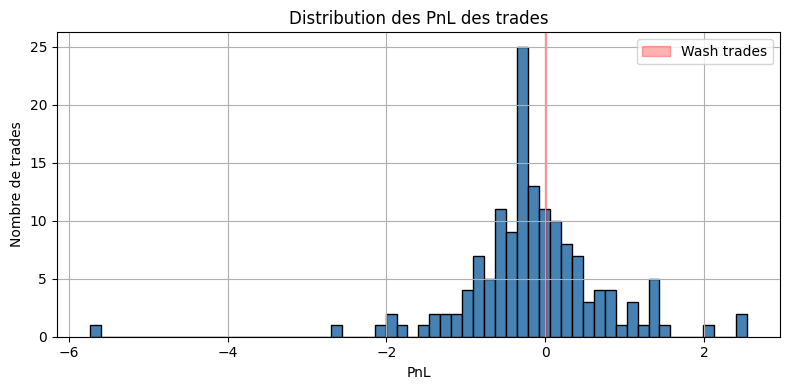

In [12]:
# ETAPE 3.1 : Visualisation des wash trades

trades_df['PnL'] = pd.to_numeric(trades_df['PnL'], errors='coerce')

seuil_wash = 0.01

wash_trades = trades_df[(trades_df['PnL'] > -seuil_wash) & (trades_df['PnL'] < seuil_wash)]
nb_wash = len(wash_trades)
pourcentage_wash = nb_wash / len(trades_df) * 100

print(f"Nombre de wash trades        : {nb_wash}")
print(f"Proportion des wash trades   : {pourcentage_wash:.2f}%")

plt.figure(figsize=(8, 4))
plt.hist(trades_df['PnL'], bins=60, color='steelblue', edgecolor='black')
plt.title("Distribution des PnL des trades")
plt.xlabel("PnL")
plt.ylabel("Nombre de trades")
plt.axvspan(-seuil_wash, seuil_wash, color='red', alpha=0.3, label='Wash trades')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

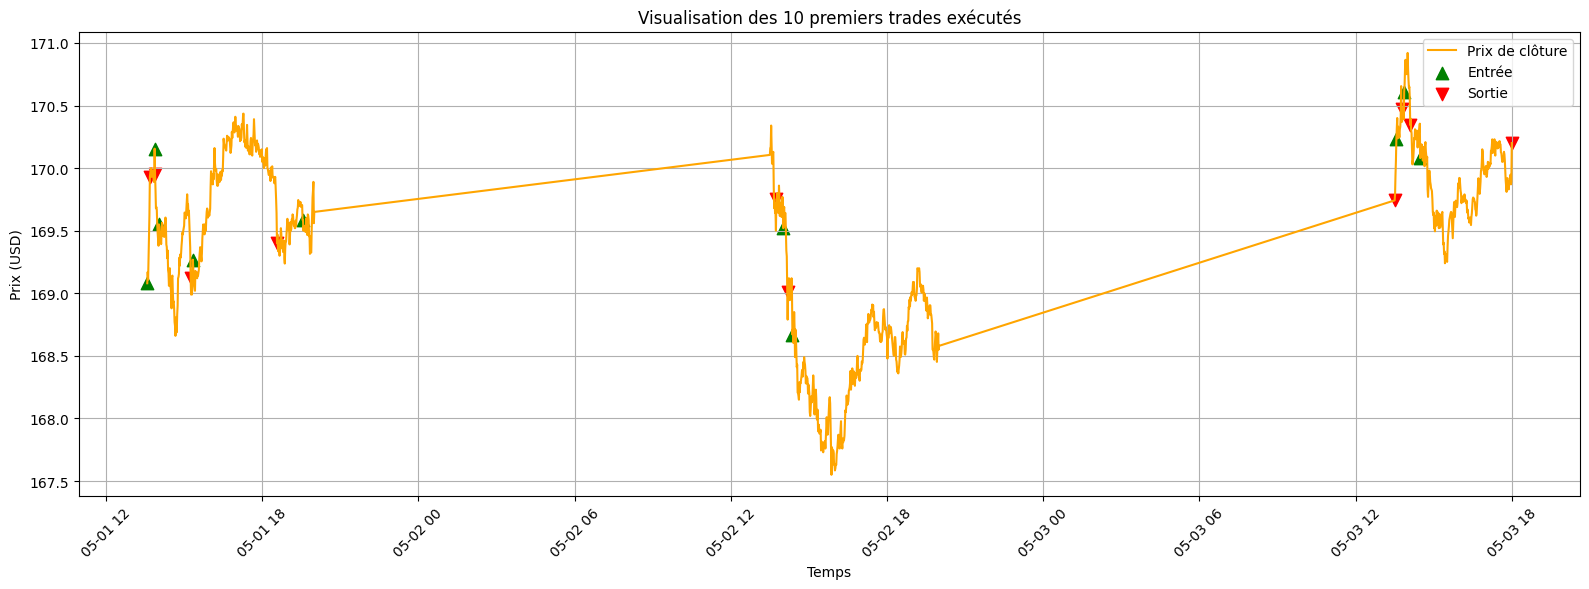

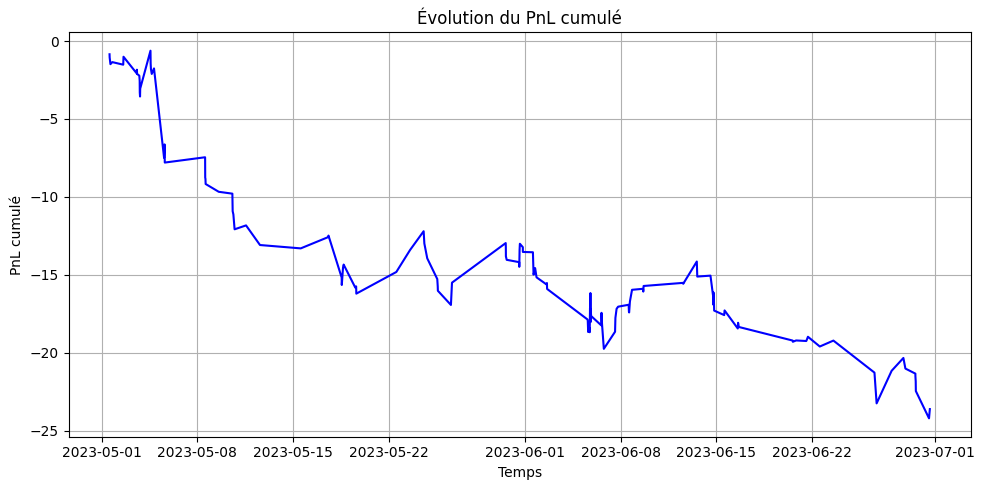

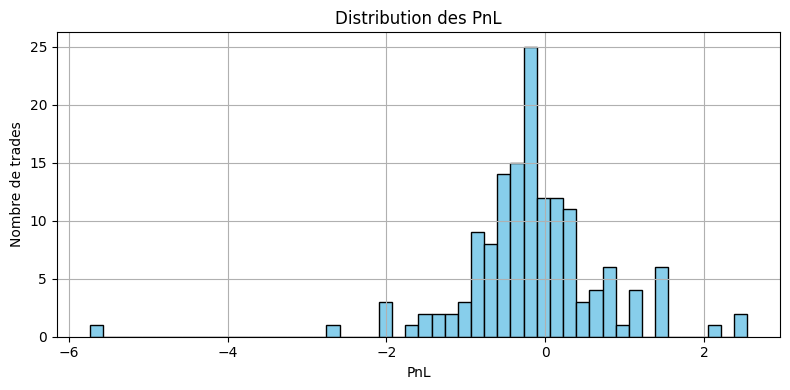

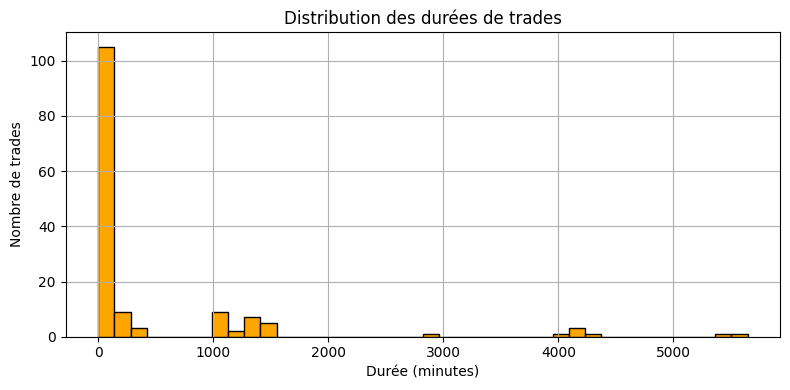

Nombre total de trades       : 148
Trades gagnants              : 53
Trades perdants              : 95
Taux de réussite             : 35.81%
Gain moyen                   : 0.6516
Perte moyenne                : -0.6121
Plus gros gain               : 2.5400
Plus grosse perte            : -5.7350
PnL total                    : -23.6127


In [13]:
#ETAPE 3.2 : Visualisation de 10 premiers trades

trades_df['entry_time'] = pd.to_datetime(trades_df['entry_time'], errors='coerce')
trades_df['exit_time'] = pd.to_datetime(trades_df['exit_time'], errors='coerce')
df_with_targets.index = pd.to_datetime(df_with_targets.index, errors='coerce')

trades_sample = trades_df.head(10)
start_time = trades_sample['entry_time'].min()
end_time = trades_sample['exit_time'].max()

prix_sample = df_with_targets.loc[start_time:end_time]

plt.figure(figsize=(16, 6))
plt.plot(prix_sample.index, prix_sample['close'], label='Prix de clôture', color='orange')
plt.scatter(trades_sample['entry_time'], trades_sample['entry_price'], marker='^', color='green', s=80, label='Entrée')
plt.scatter(trades_sample['exit_time'], trades_sample['exit_price'], marker='v', color='red', s=80, label='Sortie')
plt.title("Visualisation des 10 premiers trades exécutés")
plt.xlabel("Temps")
plt.ylabel("Prix (USD)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# ETAPE 3.3 : Analyse des performances des trades

trades_df['PnL'] = pd.to_numeric(trades_df['PnL'], errors='coerce')
total_trades = len(trades_df)

winning_trades = trades_df[trades_df['PnL'] > 0]
losing_trades = trades_df[trades_df['PnL'] <= 0]

nb_winning = len(winning_trades)
nb_losing = len(losing_trades)

win_rate = nb_winning / total_trades * 100 if total_trades else 0

avg_gain = winning_trades['PnL'].mean()
avg_loss = losing_trades['PnL'].mean()

max_gain = trades_df['PnL'].max()
max_loss = trades_df['PnL'].min()

total_pnl = trades_df['PnL'].sum()

# Courbe PnL cumulé
trades_df_sorted = trades_df.sort_values(by='exit_time')
trades_df_sorted['PnL_cumule'] = trades_df_sorted['PnL'].cumsum()

plt.figure(figsize=(10, 5))
plt.plot(trades_df_sorted['exit_time'], trades_df_sorted['PnL_cumule'], color='blue')
plt.title("Évolution du PnL cumulé")
plt.xlabel("Temps")
plt.ylabel("PnL cumulé")
plt.grid(True)
plt.tight_layout()
plt.show()

# Histogramme des PnL
plt.figure(figsize=(8, 4))
plt.hist(trades_df['PnL'], bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution des PnL")
plt.xlabel("PnL")
plt.ylabel("Nombre de trades")
plt.grid(True)
plt.tight_layout()
plt.show()

# Histogramme des durées
trades_df['duration'] = trades_df['exit_time'] - trades_df['entry_time']
trades_df['duration_min'] = trades_df['duration'].dt.total_seconds() / 60

plt.figure(figsize=(8, 4))
plt.hist(trades_df['duration_min'], bins=40, color='orange', edgecolor='black')
plt.title("Distribution des durées de trades")
plt.xlabel("Durée (minutes)")
plt.ylabel("Nombre de trades")
plt.grid(True)
plt.tight_layout()
plt.show()

# Résumé
print(f"Nombre total de trades       : {total_trades}")
print(f"Trades gagnants              : {nb_winning}")
print(f"Trades perdants              : {nb_losing}")
print(f"Taux de réussite             : {win_rate:.2f}%")
print(f"Gain moyen                   : {avg_gain:.4f}")
print(f"Perte moyenne                : {avg_loss:.4f}")
print(f"Plus gros gain               : {max_gain:.4f}")
print(f"Plus grosse perte            : {max_loss:.4f}")
print(f"PnL total                    : {total_pnl:.4f}")


## 4. Création du modèles LSTM 

In [14]:
# ETAPE 4.1 : Chargement des données pour l’IA

df = pd.read_csv("../data/out_training.csv", index_col="timestamp", parse_dates=True)
df = df.dropna()

features = ['open', 'high', 'low', 'close', 'volume',
            'RSI', 'MACD', 'OBV', 'Bollinger_%B', 'volatilite', 'ADX']
target_col = 'Target'

In [15]:
# ETAPE 4.2 : Normalisation & construction des séquences

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df[features])

sequence_length = 30
X, y = [], []

for i in range(sequence_length, len(scaled_features)):
    X.append(scaled_features[i - sequence_length:i])
    y.append(df[target_col].iloc[i])

X = np.array(X)
y = np.array(y)


In [16]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

X_flat = X.reshape((X.shape[0], -1))

counter = Counter(y)
total = sum(counter.values())

ros_strategy = {
    -1: int(counter[0] * 0.9),  
     0: counter[0],             
     1: int(counter[0] * 0.9)   
}

ros = RandomOverSampler(sampling_strategy=ros_strategy, random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_flat, y)

# Retour au format 3D
X_balanced = X_resampled.reshape((-1, sequence_length, X.shape[2]))
y_balanced = y_resampled

print("Distribution après rééquilibrage :", Counter(y_balanced))


Distribution après rééquilibrage : Counter({0: 15483, 1: 13934, -1: 13934})


In [17]:
# ETAPE 4.4 : Split des données & one-hot encoding

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import numpy as np

# Décalage des classes : [-1, 0, 1] → [0, 1, 2]
y_adjusted = y_balanced + 1

# Découpage train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_adjusted, test_size=0.2, shuffle=False
)

# Encodage one-hot pour classification catégorielle
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

# Vérification des dimensions
print("X_train shape :", X_train.shape)
print("y_train_cat shape :", y_train_cat.shape)

# Vérification de la distribution des classes
print("Classes dans y_train :", np.unique(y_train, return_counts=True))
print("Classes dans y_test :", np.unique(y_test, return_counts=True))



X_train shape : (34680, 30, 11)
y_train_cat shape : (34680, 3)
Classes dans y_train : (array([0, 1, 2]), array([13934, 15483,  5263]))
Classes dans y_test : (array([2]), array([8671]))


In [18]:
# ETAPE 4.5 : Définition du modèle LSTM

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

def create_lstm_model(input_shape, num_classes=3):
    model = Sequential()

    # 1er bloc LSTM avec retour de séquence
    model.add(LSTM(units=64, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.3))  # Dropout un peu plus fort
    model.add(BatchNormalization())

    # 2e bloc LSTM
    model.add(LSTM(units=32))
    model.add(Dropout(0.3))

    # Couche dense
    model.add(Dense(units=32, activation='relu'))
    model.add(Dense(units=num_classes, activation='softmax'))

    # Compilation
    model.compile(
        optimizer=Adam(learning_rate=0.0005),  # Apprentissage plus fin
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Création du modèle
model = create_lstm_model(input_shape=(X_train.shape[1], X_train.shape[2]))
model.summary()



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,283 (130.01 KB)

 Trainable params: 33,155 (129.51 KB)

 Non-trainable params: 128 (512.00 B)

In [19]:
# ETAPE 4.6 : Entraînement du modèle avec EarlyStopping

from tensorflow.keras.callbacks import EarlyStopping

class_weights = {
    0: 1.11,  
    1: 1.11,  
    2: 0.83    
}

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train_cat,
    epochs=40,
    batch_size=64,
    validation_data=(X_test, y_test_cat),
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/40
542/542 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.5009 - loss: 1.0198 - val_accuracy: 0.0000e+00 - val_loss: 1.4795
Epoch 2/40
542/542 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.5939 - loss: 0.9202 - val_accuracy: 0.0000e+00 - val_loss: 1.5903
Epoch 3/40
542/542 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.6023 - loss: 0.8956 - val_accuracy: 0.0017 - val_loss: 2.0220
Epoch 4/40
542/542 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.6201 - loss: 0.8623 - val_accuracy: 0.0281 - val_loss: 1.7602
Epoch 5/40
542/542 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.6271 - loss: 0.8455 - val_accuracy: 0.1135 - val_loss: 1.7589
Epoch 6/40
542/542 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.6465 - loss: 0.8169 - val_accuracy: 0.2039 - val_loss: 1.6109
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


In [20]:
# ETAPE 4.7 : Sauvegarde du modèle & scaler
from joblib import dump

model.save("model_lstm.h5")
dump(scaler, "scaler_lstm.pkl")

['scaler_lstm.pkl']

## 5. Analyse et vérification du tranning du modèles

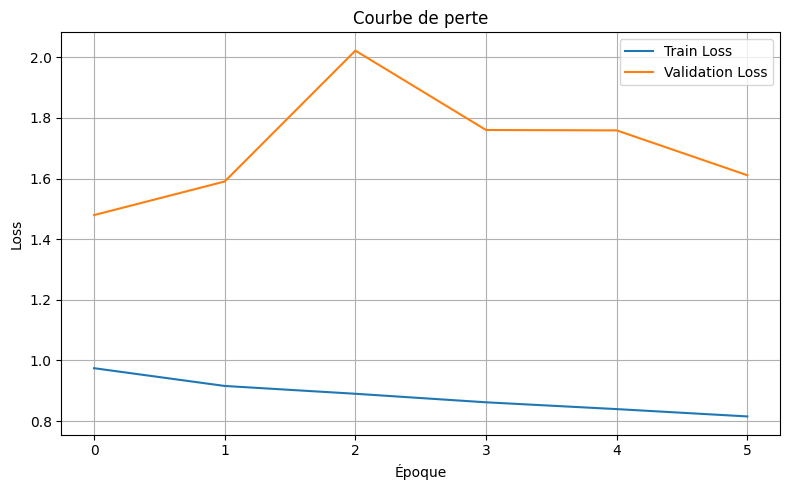

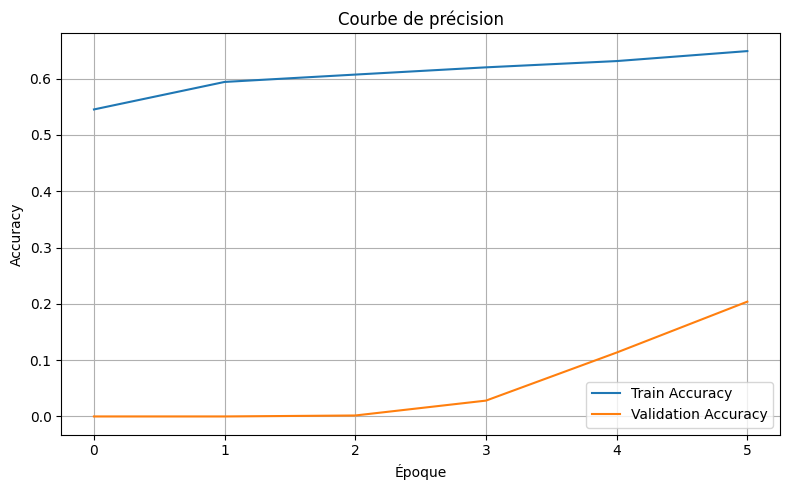

271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [21]:
# ETAPE 5.1 : Visualisation des courbes de perte et précision

# Courbes de perte
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Courbe de perte")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Courbes de précision
if 'accuracy' in history.history:
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title("Courbe de précision")
    plt.xlabel("Époque")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Prédictions
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Si y_test est one-hot encoded
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test


<Figure size 600x600 with 0 Axes>

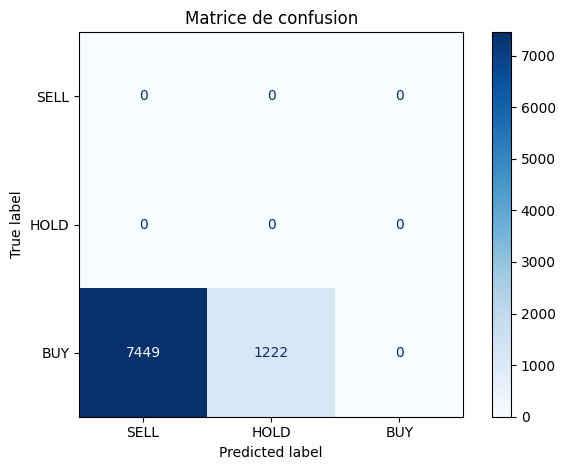

Rapport de classification :

              precision    recall  f1-score   support

        SELL      0.000     0.000     0.000       0.0
        HOLD      0.000     0.000     0.000       0.0
         BUY      0.000     0.000     0.000    8671.0

    accuracy                          0.000    8671.0
   macro avg      0.000     0.000     0.000    8671.0
weighted avg      0.000     0.000     0.000    8671.0



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_pr

In [22]:
# ETAPE 5.2 : Matrice de confusion et rapport

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
class_names = ['SELL', 'HOLD', 'BUY']

plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format='d')
plt.title("Matrice de confusion")
plt.grid(False)
plt.tight_layout()
plt.show()

# Rapport de classification
report = classification_report(y_true, y_pred, target_names=class_names, digits=3)
print("Rapport de classification :\n")
print(report)

## 6. Teste du modèles avec la donnée historique

In [23]:
# ETAPE 6.1 : Chargement de la donnée historique

df_ia = pd.read_csv("../data/out_signal.csv", index_col='timestamp', parse_dates=True)
df_ia = df_ia.dropna()


In [24]:
df_ia.head()

,open,high,low,close,volume,change1m,volatilite,perf_open,RSI,MACD,OBV,Bollinger_%B,ADX,EMA50,EMA200,ATR,CCI,StochRSI,Signal
timestamp,,,,,,,,,,,,,,,,,,,
2023-05-01 13:57:00+00:00,169.685,169.7151,169.61,169.665,124962,-0.014674,0.155229,0.227434,33.720814,-0.044239,1646708,0.083648,27.981959,169.613358,169.704662,0.217836,-66.708584,0.0,HOLD
2023-05-01 13:58:00+00:00,169.680,169.6900,169.50,169.550,122686,-0.067781,0.178613,0.159499,29.597388,-0.066065,1524022,0.018032,28.500959,169.613358,169.704662,0.215848,-121.478044,0.0,HOLD
2023-05-01 13:59:00+00:00,169.550,169.5500,169.44,169.480,113930,-0.041286,0.203117,0.118147,29.597388,-0.085511,1410092,0.039061,29.630752,169.613358,169.704662,0.208287,-171.616946,0.0,HOLD
2023-05-01 14:00:00+00:00,169.470,169.5000,169.26,169.430,205135,-0.029502,0.225778,0.088611,25.736880,-0.100054,1204957,0.075460,31.545251,169.613358,169.704662,0.210552,-196.493019,0.0,HOLD
2023-05-01 14:01:00+00:00,169.430,169.4300,169.29,169.380,143168,-0.029511,0.242898,0.059074,23.976405,-0.111003,1061789,0.102357,33.930525,169.613358,169.704662,0.205513,-167.780474,0.0,HOLD


In [25]:
# ETAPE 6.2 : Prédiction sur la donnée historique

df_ia['timestamp'] = df_ia.index
df_ia = df_ia.iloc[-len(y_pred_prob):].copy()

features = [
    'open', 'high', 'low', 'close', 'volume',
    'RSI', 'MACD', 'OBV', 'Bollinger_%B', 'volatilite', 'ADX'
]

features = [f for f in features if f in df_ia.columns]
print("Colonnes utilisées pour la prédiction :", features)

X_ia_scaled = scaler.transform(df_ia[features])

sequence_length = 60
X_ia = []

for i in range(sequence_length, len(X_ia_scaled)):
    X_ia.append(X_ia_scaled[i-sequence_length:i])

X_ia = np.array(X_ia)

# Remettre le timestamp comme colonne
df_ia = df_ia.iloc[-len(y_pred_prob):].copy()
df_ia['timestamp'] = df_ia.index  



Colonnes utilisées pour la prédiction : ['open', 'high', 'low', 'close', 'volume', 'RSI', 'MACD', 'OBV', 'Bollinger_%B', 'volatilite', 'ADX']


In [26]:
# ETAPE 6.3 : Filtrage des signaux IA et fusion avec règles

signal_map = {0: -1, 1: 0, 2: 1}

buy_prob = y_pred_prob[:, 2]
sell_prob = y_pred_prob[:, 0]

# Tronquer df_ia pour correspondre à la taille des prédictions
df_ia = df_ia.copy()
df_ia = df_ia.iloc[-len(y_pred_prob):].copy()

df_ia['buy_prob'] = buy_prob
df_ia['sell_prob'] = sell_prob

y_pred_labels = np.argmax(y_pred_prob, axis=1)
df_ia['model_prediction'] = [signal_map[v] for v in y_pred_labels]

# Seuils souples pour limiter les faux signaux
threshold_buy = 0.5
threshold_sell = 0.5

# 💡 Étape 1 : Définir une nouvelle logique 100% basée sur l'IA (sans utiliser 'Signal' manuel)
def ia_only_signal(row):
    # Seuils personnalisables (ex. : confiance minimale de 60%)
    if row['buy_prob'] >= 0.6 and row['buy_prob'] > row['sell_prob']:
        return 'BUY'
    elif row['sell_prob'] >= 0.6 and row['sell_prob'] > row['buy_prob']:
        return 'SELL'
    else:
        return 'HOLD'

# 💡 Étape 2 : Appliquer cette logique aux prédictions de l'IA
df_ia['Filtered_Signal'] = df_ia.apply(ia_only_signal, axis=1)


In [27]:
df_ia.columns

Index(['open', 'high', 'low', 'close', 'volume', 'change1m', 'volatilite',
       'perf_open', 'RSI', 'MACD', 'OBV', 'Bollinger_%B', 'ADX', 'EMA50',
       'EMA200', 'ATR', 'CCI', 'StochRSI', 'Signal', 'timestamp', 'buy_prob',
       'sell_prob', 'model_prediction', 'Filtered_Signal'],
      dtype='object')

In [28]:
print(df_ia[['Filtered_Signal']].tail(100))


                          Filtered_Signal
timestamp                                
2023-06-30 18:21:00+00:00            HOLD
2023-06-30 18:22:00+00:00            HOLD
2023-06-30 18:23:00+00:00            SELL
2023-06-30 18:24:00+00:00            SELL
2023-06-30 18:25:00+00:00            HOLD
...                                   ...
2023-06-30 19:56:00+00:00            HOLD
2023-06-30 19:57:00+00:00            SELL
2023-06-30 19:58:00+00:00            HOLD
2023-06-30 19:59:00+00:00            HOLD
2023-06-30 20:00:00+00:00            SELL

[100 rows x 1 columns]


In [29]:
# ETAPE 6.4 : Simulation des trades sur signal filtré (corrigée et sécurisée)

# 1. Remplace la colonne de signal manuellement
df_filtered = df_ia.copy()
df_filtered['Signal'] = df_filtered['Filtered_Signal']
df_filtered.index = pd.to_datetime(df_filtered['timestamp'])

# 2. Supprimer les signaux consécutifs identiques
df_filtered['Previous_Signal'] = df_filtered['Signal'].shift(1)
df_filtered = df_filtered[(df_filtered['Signal'] != df_filtered['Previous_Signal']) | (df_filtered['Previous_Signal'].isna())]
df_filtered.drop(columns=['Previous_Signal'], inplace=True)

# 3. Simulation des trades
trades_df = generate_trades_with_duration_filter(
    df_filtered,
    min_duration=1,
    max_duration=300,
    stop_loss_pct=0.01,
    verbose=True  # Pour le debug
)

# 4. Sauvegarde
trades_df.to_csv("../data/out_trades_ia.csv", index=False)
print("Nombre de trades exécutés :", len(trades_df))


✅ Entrée SELL à 2023-05-30 18:57:00+00:00 @ 177.61
🔁 Sortie SELL à 2023-06-01 15:15:00+00:00 @ 179.54 | PnL: -1.9300, durée: 208 min
✅ Entrée SELL à 2023-06-01 15:22:00+00:00 @ 179.28
🔁 Sortie SELL à 2023-06-02 13:32:00+00:00 @ 181.56 | PnL: -2.2800, durée: 102 min
✅ Entrée SELL à 2023-06-02 13:36:00+00:00 @ 180.73
🔁 Sortie SELL à 2023-06-05 13:37:00+00:00 @ 183.29 | PnL: -2.5601, durée: 142 min
✅ Entrée SELL à 2023-06-05 13:43:00+00:00 @ 183.69
🔁 Sortie SELL à 2023-06-06 19:11:00+00:00 @ 179.48 | PnL: 4.2100, durée: 300 min
✅ Entrée SELL à 2023-06-06 19:14:00+00:00 @ 179.41
🔁 Sortie SELL à 2023-06-08 18:44:00+00:00 @ 179.93 | PnL: -0.5150, durée: 300 min
✅ Entrée SELL à 2023-06-08 18:50:00+00:00 @ 179.93
🔁 Sortie SELL à 2023-06-09 13:33:00+00:00 @ 182.06 | PnL: -2.1318, durée: 34 min
✅ Entrée SELL à 2023-06-09 13:41:00+00:00 @ 181.67
🔁 Sortie SELL à 2023-06-12 19:31:00+00:00 @ 183.26 | PnL: -1.5900, durée: 300 min
✅ Entrée SELL à 2023-06-12 19:35:00+00:00 @ 183.25
🔁 Sortie SELL à 2023

In [30]:
print(trades_df.head())
print("Nombre de trades exécutés :", len(trades_df))
print(df_ia['Filtered_Signal'].value_counts())



   type  entry_price                entry_time  exit_price  \
0  SELL     177.6100 2023-05-30 18:57:00+00:00     179.540   
1  SELL     179.2800 2023-06-01 15:22:00+00:00     181.560   
2  SELL     180.7299 2023-06-02 13:36:00+00:00     183.290   
3  SELL     183.6900 2023-06-05 13:43:00+00:00     179.480   
4  SELL     179.4100 2023-06-06 19:14:00+00:00     179.925   

                  exit_time     PnL  duration_min  
0 2023-06-01 15:15:00+00:00 -1.9300           208  
1 2023-06-02 13:32:00+00:00 -2.2800           102  
2 2023-06-05 13:37:00+00:00 -2.5601           142  
3 2023-06-06 19:11:00+00:00  4.2100           300  
4 2023-06-08 18:44:00+00:00 -0.5150           300  
Nombre de trades exécutés : 17
Filtered_Signal
HOLD    6122
SELL    2549
Name: count, dtype: int64


In [31]:
if not trades_df.empty:
    print("PnL total :", trades_df['PnL'].sum())
    print("Taux de réussite :", (trades_df['PnL'] > 0).mean() * 100, "%")
    print("Durée moyenne :", trades_df['duration_min'].mean(), "minutes")
    print("Gain max", trades_df['PnL'].max())
    print("Gain min", trades_df['PnL'].min())
else:
    print("Aucun trade exécuté.")


PnL total : -17.30570000000003
Taux de réussite : 17.647058823529413 %
Durée moyenne : 208.64705882352942 minutes
Gain max 4.210000000000008
Gain min -2.5601000000000056
